# Practical 12: Linear Regression using Gradient Descent

## Objective
To implement Linear Regression from scratch using Gradient Descent and evaluate performance on California Housing dataset.

## Import Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [8]:
df = pd.read_csv("california_housing_test.csv")
df.head()

,medinc,houseage,averooms,avebedrms,population,aveoccup,latitude,longitude,median_house_value
0,5.9308,35.3,6.8343,2.8272,2999.0,1.4238,38.3245,-123.2771,0.1500
1,14.2854,41.6,2.5515,2.0507,1034.0,4.7080,40.8431,-115.0666,3.3146
2,11.1139,13.8,8.8516,2.4498,2086.0,4.4671,41.5770,-117.8857,1.7318
3,9.1805,32.9,6.5180,1.8721,1000.0,2.2540,38.0443,-122.8429,1.7126
4,2.7623,30.2,2.4148,2.2601,1828.0,2.2642,32.9046,-118.8907,0.1500


## Feature & Target Split

In [9]:
X = df.drop("median_house_value", axis=1).values
y = df["median_house_value"].values

## Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2400, 8)
Test size: (600, 8)


## Feature Normalization

In [11]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

## Add Bias Term

In [12]:
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]

## Gradient Descent Implementation

In [13]:
def gradient_descent(X, y, theta, lr, epochs):
    m = len(y)
    cost_history = []

    for i in range(epochs):
        predictions = X.dot(theta)
        error = predictions - y

        gradient = (1/m) * X.T.dot(error)
        theta = theta - lr * gradient

        cost = (1/(2*m)) * np.dot(error.T, error)
        cost_history.append(cost)

    return theta, cost_history

## Train Model

In [14]:
theta = np.zeros(X_train.shape[1])

theta, cost_history = gradient_descent(
    X_train, y_train, theta, lr=0.01, epochs=1000
)

print("Final Theta:", theta[:5])

Final Theta: [ 1.18336637  1.1026504   0.02073782  0.09649255 -0.00704395]


## Prediction

In [15]:
y_pred = X_test.dot(theta)

print("Predictions:", y_pred[:5])

Predictions: [ 1.86922369 -0.28488869  2.43409924  0.51285923 -0.38026095]


## Model Evaluation

In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.44207667626042074
MSE: 0.26949180741539214
RMSE: 0.5191260034089914
R2 Score: 0.821828157129886


## Cost Function Visualization

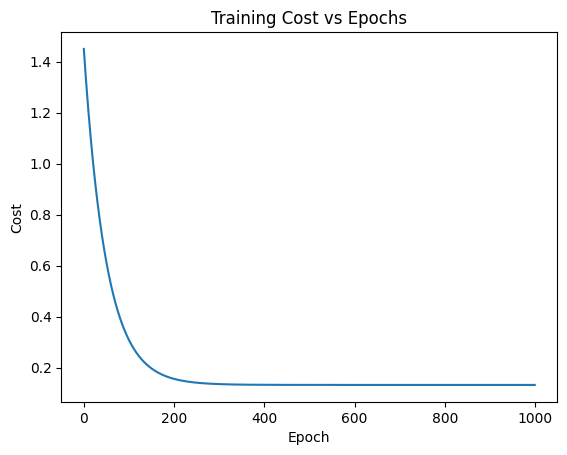

In [17]:
plt.plot(cost_history)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Training Cost vs Epochs")
plt.show()

## Conclusion

Linear Regression was successfully implemented using Gradient Descent. The cost function decreased over iterations, indicating proper convergence of the model.